In [7]:
import pandas as pd
df = pd.read_csv("../data/processed/df_merged.csv")


# Fin du nettoyage

In [8]:
# Suppression des colonnes inutiles ou redondantes
df.drop(columns={'id', 'age', 'age_group', 'bmi_cat'}, axis = 1, inplace = True)
len(df)

68636

In [9]:
# 1. Filtrage de l'IMC (Plage réaliste)
df = df[(df['bmi'] >= 15) & (df['bmi'] <= 60)]

# 2. Cohérence des pressions artérielles
df = df[df['ap_hi'] > df['ap_lo']]

# 3. Filtrage Taille et Poids
df = df[df['height'] >= 140]
df = df[df['weight'] >= 40]

print(f"Nombre de lignes restantes après nettoyage des anomalies : {len(df)}")

Nombre de lignes restantes après nettoyage des anomalies : 68381


# Feature Engineering

In [10]:
# On a déjà ajouté l'IMC
# Ajout d'une colonne pression pulsée
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']
# Une pression pulsée élevée est un marqueur fort de rigidité artérielle.

In [11]:
df

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,bmi,C_Reactive,Sodium,Saturated_Fat,hypertension_stage,pulse_pressure
0,2,168,62.0,110,80,1,1,0,0,1,0,50,21.967120,2.216181,3373.440476,26.093863,2,30
1,1,156,85.0,140,90,3,1,0,0,1,1,55,34.927679,6.242231,3317.237500,28.023627,3,50
2,1,165,64.0,130,70,3,1,0,0,0,1,51,23.507805,2.162735,3304.609137,25.664487,2,60
3,2,169,82.0,150,100,1,1,0,0,1,1,48,28.710479,3.325836,3542.421053,27.667312,3,50
4,1,156,56.0,100,60,1,1,0,0,0,0,47,23.011177,2.216181,3373.440476,26.093863,0,40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68631,2,168,76.0,120,80,1,1,1,0,1,0,52,26.927438,2.956246,3255.226837,24.976716,2,40
68632,1,158,126.0,140,90,2,2,0,0,1,1,61,50.472681,6.181304,3090.667651,26.696743,3,50
68633,2,183,105.0,180,90,3,1,0,1,0,1,52,31.353579,6.242231,3317.237500,28.023627,3,90
68634,1,163,72.0,135,80,1,2,0,0,0,1,61,27.099251,3.332790,3115.806584,26.017539,2,55


## Matrice de corrélation

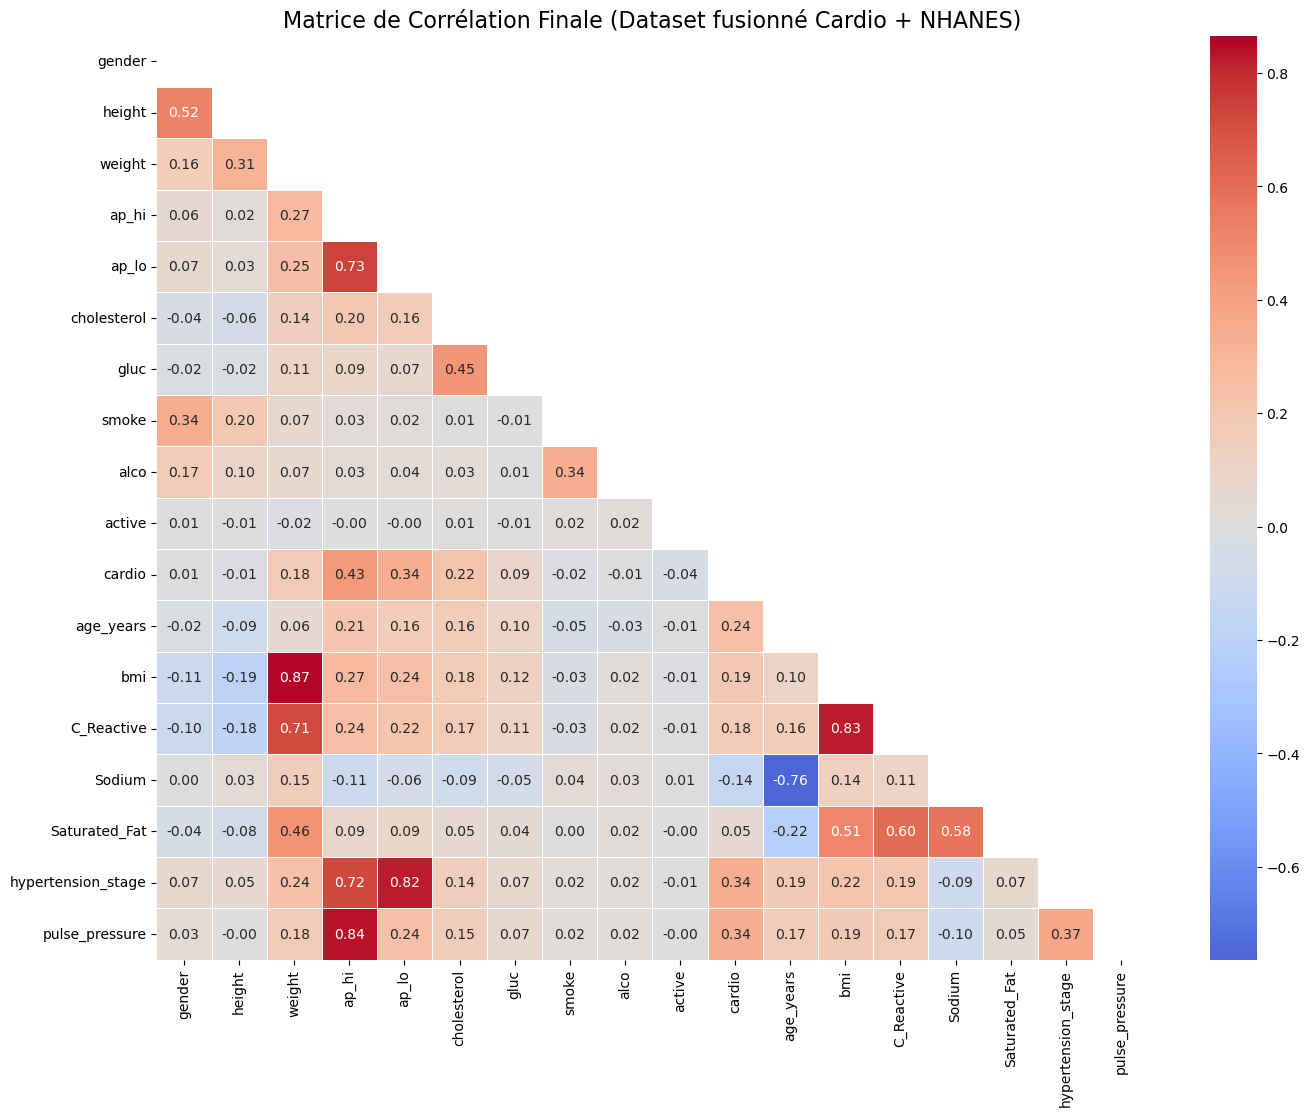


--- Corrélations les plus fortes avec le risque cardiovasculaire ---
cardio                1.000000
ap_hi                 0.429092
hypertension_stage    0.342568
ap_lo                 0.342397
pulse_pressure        0.337500
age_years             0.239324
cholesterol           0.221224
bmi                   0.192512
C_Reactive            0.182687
weight                0.180495
gluc                  0.089059
Saturated_Fat         0.053177
gender                0.006827
alco                 -0.008491
height               -0.013013
smoke                -0.016510
active               -0.037926
Sodium               -0.138527
Name: cardio, dtype: float64


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. On ne conserve que les colonnes numériques pour le calcul[cite: 2]
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

# 2. Configuration de la visualisation
plt.figure(figsize=(16, 12))

# Masque pour cacher la partie supérieure (miroir de la partie inférieure)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Création de la Heatmap[cite: 2]
sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=True,     # Affiche les valeurs
            fmt=".2f",      # 2 décimales
            cmap='coolwarm', # Dégradé bleu (négatif) au rouge (positif)
            center=0,       # Le blanc correspond à une corrélation nulle
            linewidths=.5)

plt.title('Matrice de Corrélation Finale (Dataset fusionné Cardio + NHANES)', fontsize=16)
plt.show()

# 3. Affichage rapide du lien avec la variable cible 'cardio'
if 'cardio' in corr_matrix.columns:
    print("\n--- Corrélations les plus fortes avec le risque cardiovasculaire ---")
    print(corr_matrix['cardio'].sort_values(ascending=False))

## Suppression des variables fortement corrélées : weight, C_reactive, pulse_pressure et hypertension_stage




In [13]:
df.drop(columns={'weight', 'C_Reactive', 'pulse_pressure', 'hypertension_stage'}, axis = 1, inplace = True)

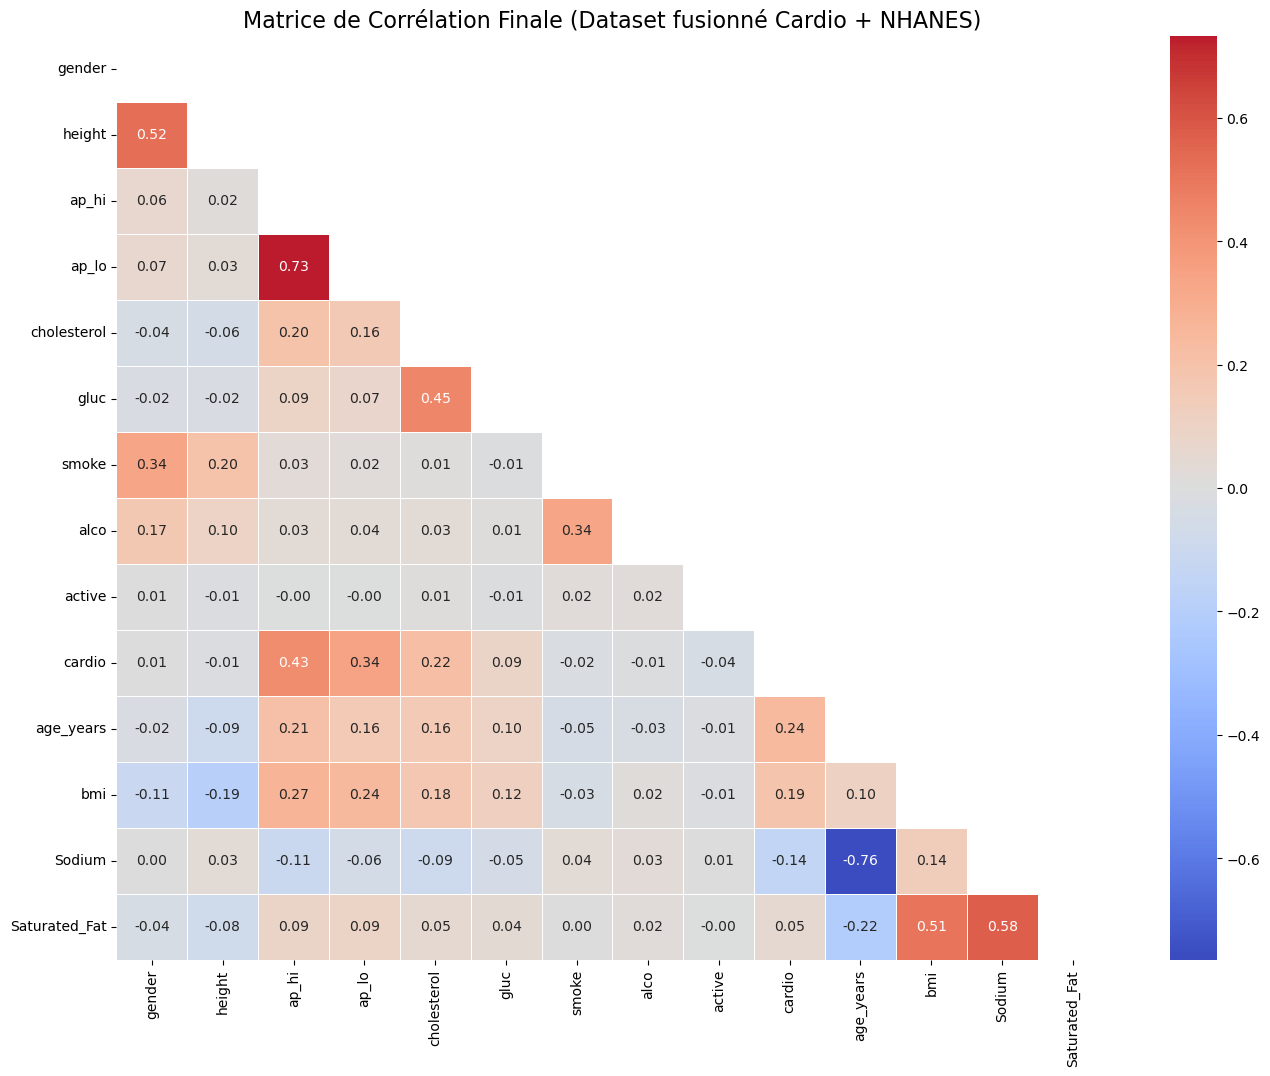


--- Corrélations les plus fortes avec le risque cardiovasculaire ---
cardio           1.000000
ap_hi            0.429092
ap_lo            0.342397
age_years        0.239324
cholesterol      0.221224
bmi              0.192512
gluc             0.089059
Saturated_Fat    0.053177
gender           0.006827
alco            -0.008491
height          -0.013013
smoke           -0.016510
active          -0.037926
Sodium          -0.138527
Name: cardio, dtype: float64


In [14]:

# 1. On ne conserve que les colonnes numériques pour le calcul[cite: 2]
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

# 2. Configuration de la visualisation
plt.figure(figsize=(16, 12))

# Masque pour cacher la partie supérieure (miroir de la partie inférieure)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Création de la Heatmap[cite: 2]
sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=True,     # Affiche les valeurs
            fmt=".2f",      # 2 décimales
            cmap='coolwarm', # Dégradé bleu (négatif) au rouge (positif)
            center=0,       # Le blanc correspond à une corrélation nulle
            linewidths=.5)

plt.title('Matrice de Corrélation Finale (Dataset fusionné Cardio + NHANES)', fontsize=16)
plt.show()

# 3. Affichage rapide du lien avec la variable cible 'cardio'
if 'cardio' in corr_matrix.columns:
    print("\n--- Corrélations les plus fortes avec le risque cardiovasculaire ---")
    print(corr_matrix['cardio'].sort_values(ascending=False))

In [15]:
df.to_csv("../data/processed/df_clean.csv", index=False)

# PCA

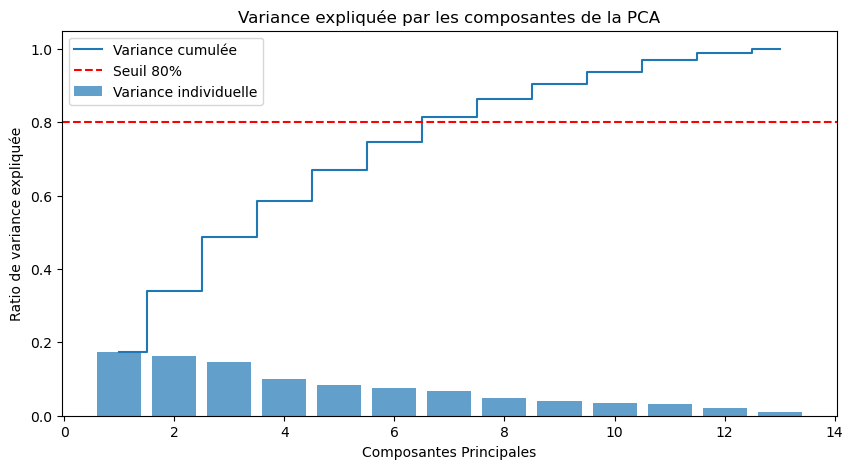

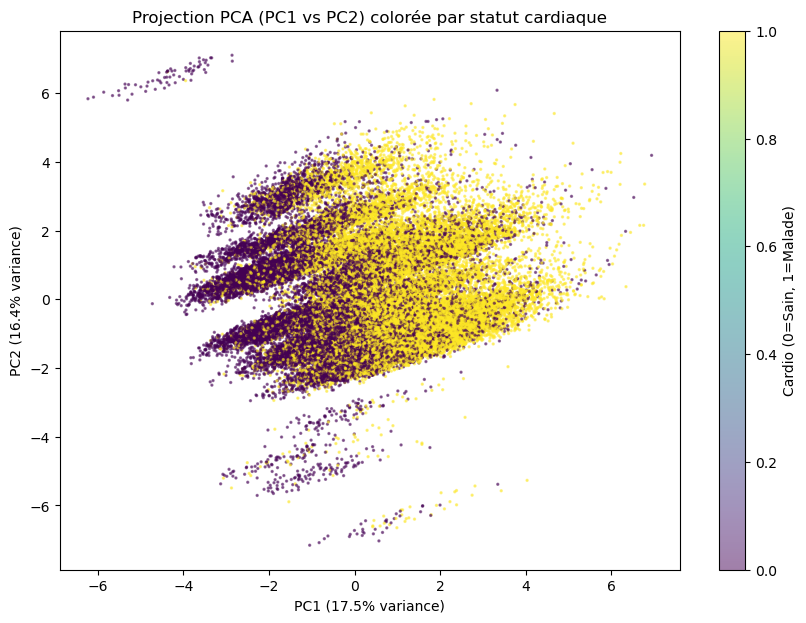


--- Contributions des variables aux 3 premières composantes ---
                    PC1       PC2       PC3
ap_hi          0.473739  0.171849  0.194571
ap_lo          0.442282  0.185451  0.205996
age_years      0.437553  0.339937  0.070112
Sodium         0.345537  0.529510  0.056511
cholesterol    0.336955  0.103730  0.008750
bmi            0.266404  0.421208  0.075818
gluc           0.255342  0.083433  0.004386
height         0.111417  0.105173  0.496921
gender         0.059520  0.084282  0.562903
smoke          0.049076  0.004651  0.466731
Saturated_Fat  0.029559  0.570667  0.007153
active         0.009601  0.000605  0.022277
alco           0.008344  0.033971  0.351537


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Préparation des données
df = pd.read_csv("../data/processed/df_clean.csv")
# On sépare la variable cible 'cardio' du reste des caractéristiques
X = df.drop('cardio', axis=1)
y = df['cardio']

# On ne garde que les colonnes numériques (au cas où il resterait des colonnes catégorielles comme bmi_cat)
X_numeric = X.select_dtypes(include=[np.number])

# 2. Standardisation (Crucial pour la PCA car les unités diffèrent : mmHg, ans, etc.)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_numeric)

# 3. Application de la PCA
# On initialise la PCA pour calculer toutes les composantes afin d'analyser la variance
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 4. Analyse de la variance expliquée
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(10, 5))
plt.bar(range(1, len(explained_variance)+1), explained_variance, alpha=0.7, label='Variance individuelle')
plt.step(range(1, len(cumulative_variance)+1), cumulative_variance, where='mid', label='Variance cumulée')
plt.axhline(y=0.8, color='r', linestyle='--', label='Seuil 80%')
plt.xlabel('Composantes Principales')
plt.ylabel('Ratio de variance expliquée')
plt.title('Variance expliquée par les composantes de la PCA')
plt.legend()
plt.show()

# 5. Visualisation des patients sur les 2 premières composantes (PC1 et PC2)
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.5, s=2)
plt.colorbar(scatter, label='Cardio (0=Sain, 1=Malade)')
plt.xlabel(f'PC1 ({explained_variance[0]:.1%} variance)')
plt.ylabel(f'PC2 ({explained_variance[1]:.1%} variance)')
plt.title('Projection PCA (PC1 vs PC2) colorée par statut cardiaque')
plt.show()

# 6. Analyse de la contribution des variables aux composantes (Cercle de corrélation)
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f'PC{i+1}' for i in range(len(X_numeric.columns))], 
    index=X_numeric.columns
)
print("\n--- Contributions des variables aux 3 premières composantes ---")
print(loadings[['PC1', 'PC2', 'PC3']].abs().sort_values(by='PC1', ascending=False))

In [19]:
# Calcul des contributions (loadings)
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f'PC{i+1}' for i in range(pca.n_components_)], 
    index=X_numeric.columns
)

# Affichage des variables les plus influentes sur PC1
print("Variables influençant le plus la séparation (PC1):")
print(loadings['PC1'].sort_values(ascending=False))

Variables influençant le plus la séparation (PC1):
ap_hi            0.473739
ap_lo            0.442282
age_years        0.437553
cholesterol      0.336955
bmi              0.266404
gluc             0.255342
alco            -0.008344
active          -0.009601
Saturated_Fat   -0.029559
smoke           -0.049076
gender          -0.059520
height          -0.111417
Sodium          -0.345537
Name: PC1, dtype: float64


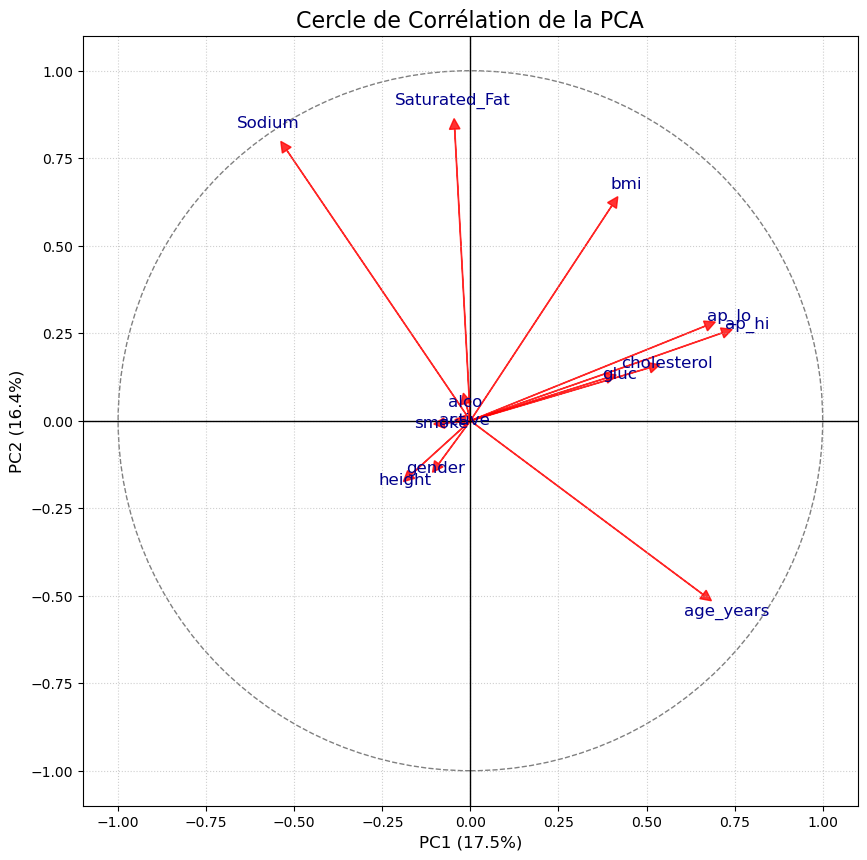

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Préparation des données (on exclut la cible 'cardio' et les colonnes non numériques)
X = df.drop(columns=['cardio', 'id', 'age_group', 'bmi_cat'], errors='ignore')
features = X.columns

# 2. Standardisation des données
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Calcul de la PCA
pca = PCA(n_components=2)
pca.fit(X_scaled)

# 4. Calcul des coordonnées des variables (Loadings)
# On multiplie les composantes par la racine carrée des valeurs propres
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

# 5. Tracé du cercle de corrélation
plt.figure(figsize=(10, 10))
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# Tracer les vecteurs des variables
for i, feature in enumerate(features):
    plt.arrow(0, 0, loadings[i, 0], loadings[i, 1], head_width=0.03, head_length=0.03, color='red', alpha=0.8)
    plt.text(loadings[i, 0] * 1.1, loadings[i, 1] * 1.1, feature, color='darkblue', ha='center', va='center', fontsize=12)

# Tracer le cercle unité
circle = plt.Circle((0,0), 1, color='gray', fill=False, linestyle='--')
plt.gca().add_artist(circle)

# Configuration des axes
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=12)
plt.title('Cercle de Corrélation de la PCA', fontsize=16)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

il n'est pas pertinent de garder la PCA
- Les deux premières composantes ne capturent que 34 % de la variance
- Chevauchement des classes : La visualisation montre que les patients sains et malades ne sont pas linéairement séparables dans cet espace réduit

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Charger les données nettoyées
df = pd.read_csv('../data/processed/df_clean.csv')

# 2. Séparer les variables explicatives (X) et la variable cible (y)
X = df.drop(columns=['cardio'])
y = df['cardio']

# 3. Split Train/Test (indispensable avant le scaling)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Initialisation du Scaler
scaler = StandardScaler()

# 5. Application du Scaling
# On "fit" sur le train et on transforme les deux
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Conversion en DataFrame pour garder les noms de colonnes
X_train_final = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_final = pd.DataFrame(X_test_scaled, columns=X.columns)

output_dir = "../data/processed/"
X_train_final.to_csv(output_dir + "X_train.csv", index=False)
X_test_final.to_csv(output_dir + "X_test.csv", index=False)
y_train.to_csv(output_dir + "y_train.csv", index=False)
y_test.to_csv(output_dir + "y_test.csv", index=False)